In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv('data/processed/nav_history_clean.csv', parse_dates=['date'])
nav = nav.sort_values(['amfi_code', 'date'])

# Pivot: dates as rows, schemes as columns
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()

# Daily returns
daily_returns = nav_pivot.pct_change().dropna(how='all')

# CAGR helper
def cagr(nav_series, years):
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    start, end = nav_series.iloc[0], nav_series.iloc[-1]
    n = years
    return (end / start) ** (1 / n) - 1

cagr_rows = []
for code in nav_pivot.columns:
    series = nav_pivot[code].dropna()
    cagr_rows.append({
        'amfi_code': code,
        'CAGR_1yr': cagr(series[series.index >= series.index.max() - pd.DateOffset(years=1)], 1),
        'CAGR_3yr': cagr(series[series.index >= series.index.max() - pd.DateOffset(years=3)], 3),
        'CAGR_5yr': cagr(series[series.index >= series.index.max() - pd.DateOffset(years=5)], 5),
    })

cagr_table = pd.DataFrame(cagr_rows)
print(nav_pivot.shape, daily_returns.shape)
cagr_table.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/nav_history_clean.csv'

In [2]:
import os
print("Current working directory:", os.getcwd())
print(os.listdir())

Current working directory: C:\Users\raghvendr shahi\Desktop\Mutual_Fund_Analytics\notebooks
['.ipynb_checkpoints', 'Performance_Analytics.ipynb', 'run_analytics.py']


In [3]:
import pandas as pd
import numpy as np

nav = pd.read_csv('../data/processed/nav_history_clean.csv', parse_dates=['date'])
nav = nav.sort_values(['amfi_code', 'date'])

nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()
daily_returns = nav_pivot.pct_change().dropna(how='all')

def cagr(nav_series, years):
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    start, end = nav_series.iloc[0], nav_series.iloc[-1]
    return (end / start) ** (1 / years) - 1

cagr_rows = []
for code in nav_pivot.columns:
    series = nav_pivot[code].dropna()
    cagr_rows.append({
        'amfi_code': code,
        'CAGR_1yr': cagr(series[series.index >= series.index.max() - pd.DateOffset(years=1)], 1),
        'CAGR_3yr': cagr(series[series.index >= series.index.max() - pd.DateOffset(years=3)], 3),
        'CAGR_5yr': cagr(series[series.index >= series.index.max() - pd.DateOffset(years=5)], 5),
    })

cagr_table = pd.DataFrame(cagr_rows)
print(nav_pivot.shape, daily_returns.shape)
cagr_table.head(10)

(1150, 40) (1149, 40)


,amfi_code,CAGR_1yr,CAGR_3yr,CAGR_5yr
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533
5,101208,0.072366,0.063158,0.057057
6,102885,0.202077,0.196673,0.158788
7,102886,-0.167975,-0.007674,0.010303
8,102887,0.135831,0.255562,0.146781
9,118632,0.339810,0.226524,0.208811


In [4]:
RISK_FREE_RATE = 0.065  # RBI repo rate proxy, annualised
daily_rf = RISK_FREE_RATE / 252

sharpe_sortino_rows = []

for code in daily_returns.columns:
    returns = daily_returns[code].dropna()
    if len(returns) < 2:
        continue

    excess_returns = returns - daily_rf

    # Sharpe Ratio
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

    # Sortino Ratio (denominator = downside deviation only, negative returns)
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else np.nan

    sharpe_sortino_rows.append({
        'amfi_code': code,
        'Sharpe_Ratio': sharpe,
        'Sortino_Ratio': sortino,
    })

sharpe_sortino_table = pd.DataFrame(sharpe_sortino_rows)
sharpe_sortino_table = sharpe_sortino_table.sort_values('Sharpe_Ratio', ascending=False)
print(sharpe_sortino_table.shape)
sharpe_sortino_table.head(10)

(40, 3)


,amfi_code,Sharpe_Ratio,Sortino_Ratio
34,148567,1.448291,2.368342
30,120843,1.306744,2.352942
36,148569,1.234930,2.135083
19,119551,1.208267,2.103952
25,120505,1.180101,2.010035
38,149323,1.132122,1.868935
2,100033,1.093699,1.823824
9,118632,1.081659,1.839859
3,101206,1.027213,1.785592
24,120504,1.026524,1.785043


In [5]:
import os

print("--- data/raw ---")
print(os.listdir('../data/raw'))

print("\n--- data/processed ---")
print(os.listdir('../data/processed'))

--- data/raw ---
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_LargeCap.csv', 'SBI_Bluechip.csv']

--- data/processed ---
['investor_transactions_clean.csv', 'nav_history_clean.csv', 'scheme_performance_clean.csv']


In [7]:
benchmark = pd.read_csv('../data/raw/10_benchmark_indices.csv')
print(benchmark.columns.tolist())
print(benchmark.head(5))
print(benchmark.shape)

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
(8050, 3)


In [9]:
from scipy import stats

# Pivot benchmark: dates as rows, index names as columns
benchmark = pd.read_csv('../data/raw/10_benchmark_indices.csv', parse_dates=['date'])
benchmark_pivot = benchmark.pivot(index='date', columns='index_name', values='close_value').sort_index()
print(benchmark_pivot.columns.tolist())  # confirm exact names, e.g. NIFTY50 / NIFTY100

benchmark_returns = benchmark_pivot.pct_change().dropna(how='all')

# Align benchmark with fund daily_returns on common dates
common_dates = daily_returns.index.intersection(benchmark_returns.index)
fund_returns_aligned = daily_returns.loc[common_dates]
nifty100_returns = benchmark_returns.loc[common_dates, 'NIFTY100']  # adjust name if different

alpha_beta_rows = []
for code in fund_returns_aligned.columns:
    y = fund_returns_aligned[code].dropna()
    x = nifty100_returns.loc[y.index].dropna()
    y = y.loc[x.index]  # ensure same index after dropna

    if len(x) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    alpha_beta_rows.append({
        'amfi_code': code,
        'Alpha': intercept * 252,
        'Beta': slope,
        'R_squared': r_value ** 2,
    })

alpha_beta_table = pd.DataFrame(alpha_beta_rows).sort_values('Alpha', ascending=False)
print(alpha_beta_table.shape)
alpha_beta_table.head(10)

['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100', 'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150']
(40, 4)


,amfi_code,Alpha,Beta,R_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


In [10]:
print("nav index dtype:", daily_returns.index.dtype)
print("benchmark index dtype:", benchmark_returns.index.dtype)
print("nav date range:", daily_returns.index.min(), "to", daily_returns.index.max())
print("benchmark date range:", benchmark_returns.index.min(), "to", benchmark_returns.index.max())
print("duplicate amfi_codes in daily_returns columns?", daily_returns.columns.duplicated().sum())
print("total unique amfi_codes:", daily_returns.columns.nunique())

nav index dtype: datetime64[us]
benchmark index dtype: datetime64[us]
nav date range: 2022-01-04 00:00:00 to 2026-05-29 00:00:00
benchmark date range: 2022-01-04 00:00:00 to 2026-05-29 00:00:00
duplicate amfi_codes in daily_returns columns? 0
total unique amfi_codes: 40


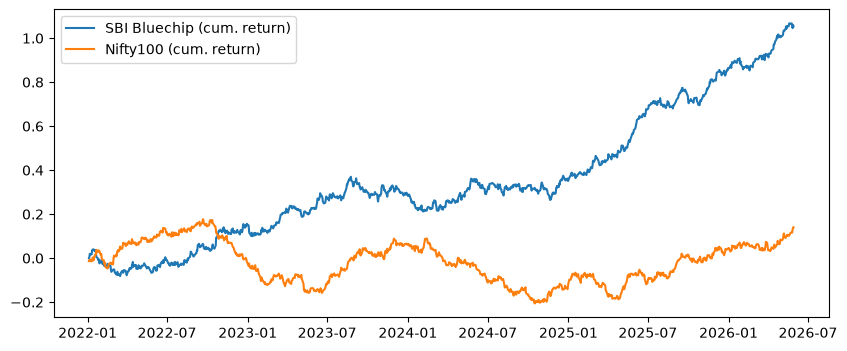

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(daily_returns.index, daily_returns[119551].cumsum(), label='SBI Bluechip (cum. return)')
ax.plot(nifty100_returns.index, nifty100_returns.cumsum(), label='Nifty100 (cum. return)')
ax.legend()
plt.show()

In [12]:
print("alpha_beta_table shape:", alpha_beta_table.shape)
print("duplicated amfi_codes:", alpha_beta_table['amfi_code'].duplicated().sum())

alpha_beta_table shape: (40, 4)
duplicated amfi_codes: 0


In [13]:
max_dd_rows = []

for code in nav_pivot.columns:
    series = nav_pivot[code].dropna()
    running_max = series.cummax()
    drawdown = (series / running_max) - 1
    max_drawdown = drawdown.min()
    max_dd_rows.append({
        'amfi_code': code,
        'Max_Drawdown': max_drawdown,
    })

max_dd_table = pd.DataFrame(max_dd_rows).sort_values('Max_Drawdown')
print(max_dd_table.shape)
max_dd_table.head(10)

(40, 2)


,amfi_code,Max_Drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [14]:
# Merge all metrics into one master table
scorecard = cagr_table.merge(sharpe_sortino_table, on='amfi_code') \
                       .merge(alpha_beta_table, on='amfi_code') \
                       .merge(max_dd_table, on='amfi_code')

# Pull expense_ratio_pct from the reference file to use in scoring
expense_ref = pd.read_csv('../data/processed/scheme_performance_clean.csv')[['amfi_code', 'expense_ratio_pct']]
scorecard = scorecard.merge(expense_ref, on='amfi_code')

print(scorecard.shape)
scorecard.head()

(40, 11)


,amfi_code,CAGR_1yr,CAGR_3yr,CAGR_5yr,Sharpe_Ratio,Sortino_Ratio,Alpha,Beta,R_squared,Max_Drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,-0.201517,-0.348196,0.037476,-0.058268,0.002665,-0.247344,1.55
1,100025,0.037050,0.039164,0.039127,-0.567095,-0.915371,0.042818,0.001158,0.000015,-0.043083,0.56
2,100033,0.532324,0.324425,0.260741,1.093699,1.823824,0.271954,0.005104,0.000012,-0.162172,1.38
3,101206,0.479241,0.289677,0.204427,1.027213,1.785592,0.213998,0.021086,0.000348,-0.112916,1.60
4,101207,-0.239860,-0.041524,0.069533,0.162661,0.274615,0.108971,-0.065289,0.001064,-0.354469,1.53


In [15]:
def to_percentile_rank(series, ascending=True):
    return series.rank(pct=True, ascending=ascending) * 100

scorecard['rank_3yr_return']  = to_percentile_rank(scorecard['CAGR_3yr'], ascending=True)
scorecard['rank_sharpe']      = to_percentile_rank(scorecard['Sharpe_Ratio'], ascending=True)
scorecard['rank_alpha']       = to_percentile_rank(scorecard['Alpha'], ascending=True)
scorecard['rank_expense']     = to_percentile_rank(scorecard['expense_ratio_pct'], ascending=False)  # lower expense = better
scorecard['rank_max_dd']      = to_percentile_rank(scorecard['Max_Drawdown'], ascending=True)  # less negative = better

scorecard['Fund_Score'] = (
    0.30 * scorecard['rank_3yr_return'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_max_dd']
)

scorecard = scorecard.sort_values('Fund_Score', ascending=False)
scorecard.to_csv('fund_scorecard.csv', index=False)
print(scorecard.shape)
scorecard[['amfi_code', 'Fund_Score', 'CAGR_3yr', 'Sharpe_Ratio', 'Alpha', 'expense_ratio_pct', 'Max_Drawdown']].head(10)

(40, 17)


,amfi_code,Fund_Score,CAGR_3yr,Sharpe_Ratio,Alpha,expense_ratio_pct,Max_Drawdown
34,148567,86.2500,0.340009,1.448291,0.269838,1.46,-0.112657
25,120505,82.2500,0.317775,1.180101,0.292636,1.36,-0.181885
30,120843,82.0000,0.295828,1.306744,0.273305,1.45,-0.129740
2,100033,80.7500,0.324425,1.093699,0.271954,1.38,-0.162172
24,120504,80.0000,0.324874,1.026524,0.211948,0.80,-0.125883
16,119094,77.0000,0.351118,0.998231,0.260767,1.38,-0.209609
19,119551,74.8125,0.304565,1.208267,0.232010,1.54,-0.150124
36,148569,73.6875,0.291789,1.234930,0.282704,1.60,-0.163967
3,101206,68.1875,0.289677,1.027213,0.213998,1.60,-0.112916
21,119598,67.3750,0.266699,0.945308,0.303370,1.43,-0.287060


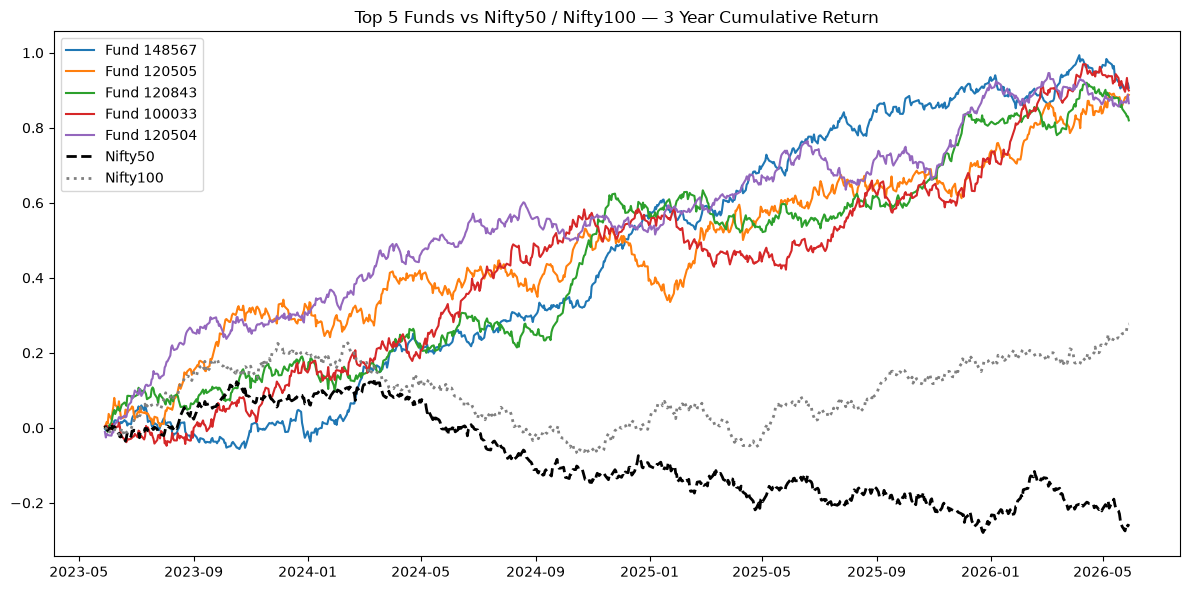

,amfi_code,Tracking_Error
0,148567,0.187867
1,120505,0.232515
2,120843,0.206410
3,100033,0.224838
4,120504,0.187312


In [16]:
top5_codes = scorecard.head(5)['amfi_code'].tolist()
three_yr_start = daily_returns.index.max() - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(12, 6))

for code in top5_codes:
    series = daily_returns.loc[daily_returns.index >= three_yr_start, code].dropna()
    ax.plot(series.index, series.cumsum(), label=f'Fund {code}')

nifty50_3yr = benchmark_returns.loc[benchmark_returns.index >= three_yr_start, 'NIFTY50'].dropna()
nifty100_3yr = benchmark_returns.loc[benchmark_returns.index >= three_yr_start, 'NIFTY100'].dropna()

ax.plot(nifty50_3yr.index, nifty50_3yr.cumsum(), label='Nifty50', linewidth=2, linestyle='--', color='black')
ax.plot(nifty100_3yr.index, nifty100_3yr.cumsum(), label='Nifty100', linewidth=2, linestyle=':', color='grey')

ax.set_title('Top 5 Funds vs Nifty50 / Nifty100 — 3 Year Cumulative Return')
ax.legend()
plt.tight_layout()
plt.savefig('benchmark_comparison_chart.png', dpi=150)
plt.show()

# Tracking error for each top-5 fund vs Nifty100
tracking_errors = []
for code in top5_codes:
    fund_ret = daily_returns.loc[daily_returns.index >= three_yr_start, code].dropna()
    common = fund_ret.index.intersection(nifty100_3yr.index)
    te = (fund_ret.loc[common] - nifty100_3yr.loc[common]).std() * np.sqrt(252)
    tracking_errors.append({'amfi_code': code, 'Tracking_Error': te})

pd.DataFrame(tracking_errors)

In [17]:
alpha_beta_table.to_csv('alpha_beta.csv', index=False)
print("Saved alpha_beta.csv")

Saved alpha_beta.csv
